# Credit Card Fraud Detection
### A full imbalanced-classification project: EDA → resampling → modeling → cost-based evaluation

**Dataset note:** This notebook uses a synthetic dataset generated to mimic the structure and
class imbalance of the well-known Kaggle *Credit Card Fraud Detection* dataset
(284,807 transactions, 0.17% fraud, `Time`, `Amount`, PCA features `V1`-`V28`, target `Class`).

To use the **real** dataset instead: download it from
[kaggle.com/datasets/mlg-ulb/creditcardfraud](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud),
place `creditcard.csv` in the `data/` folder, and re-run — every cell below works unchanged.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_recall_curve, average_precision_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import RandomUnderSampler

import xgboost as xgb

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
RANDOM_STATE = 42


## 1. Load data

In [2]:
df = pd.read_csv("data/creditcard.csv")
print(df.shape)
df.head()

(60000, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,48684.0,2.300336,3.441974,0.388786,0.416436,2.089125,1.299650,0.762163,-1.098645,-4.848068,...,1.306223,4.805822,1.057397,0.389231,1.389218,1.552073,0.869395,-0.333262,146.48,0
1,151883.0,1.259245,2.349136,-0.592501,-0.788040,-1.093696,1.016715,-1.015342,-1.666226,1.149347,...,2.096093,-1.368130,-0.857586,4.026451,1.016960,6.113276,-0.526973,-0.538911,5.64,0
2,56469.0,-0.175945,1.684446,0.193248,-5.907911,6.274846,5.289343,-0.886159,1.017609,-3.424165,...,-0.747153,4.836121,-0.124822,-0.316502,-0.872140,0.623226,1.963332,-1.148128,8.23,0
3,144115.0,0.013009,-2.701519,-1.172528,0.011698,-3.577429,0.997688,-1.975209,-0.223878,-1.781928,...,-1.562120,-2.626038,0.728476,-0.016200,-0.344913,2.094107,0.513860,1.235946,35.66,0
4,55545.0,-1.079147,-0.085588,0.003430,-0.701043,1.658212,0.814108,0.781760,1.634103,-3.008425,...,1.468388,1.822136,1.507058,1.232553,0.482771,1.923641,-0.593439,0.438825,67.92,0


## 2. Exploratory Data Analysis

### 2.1 Class imbalance — the core challenge
Fraud detection is the textbook imbalanced-classification problem. Before touching any model,
you need to *see* just how skewed the target is — this number should shape every decision that
follows (metric choice, resampling, threshold).

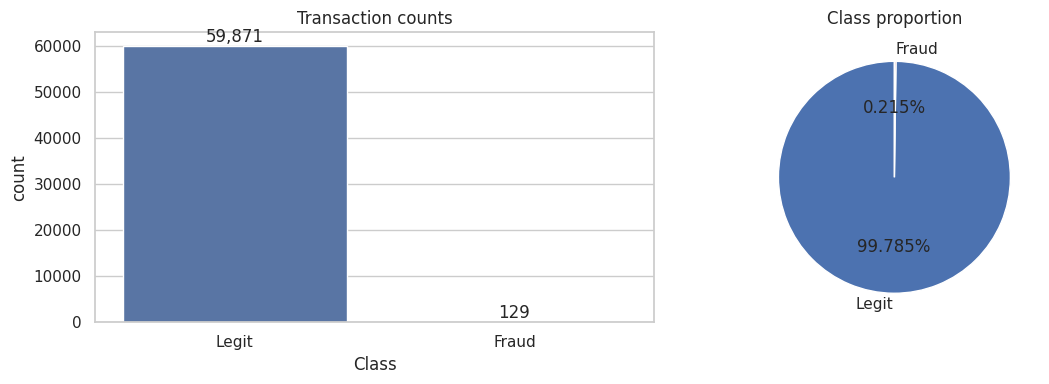

Fraud rate: 0.2150%  (129 of 60,000 transactions)

>> A model that always predicts 'legit' would score 99.78% accuracy while catching ZERO fraud. Accuracy is useless here.


In [3]:
class_counts = df["Class"].value_counts()
class_pct = df["Class"].value_counts(normalize=True) * 100

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x="Class", data=df, ax=ax[0], hue="Class", palette=["#4C72B0", "#C44E52"], legend=False)
ax[0].set_title("Transaction counts")
ax[0].set_xticks([0, 1])
ax[0].set_xticklabels(["Legit", "Fraud"])
for i, v in enumerate(class_counts):
    ax[0].text(i, v, f"{v:,}", ha="center", va="bottom")

ax[1].pie(class_counts, labels=["Legit", "Fraud"], autopct="%1.3f%%",
          colors=["#4C72B0", "#C44E52"], startangle=90)
ax[1].set_title("Class proportion")
plt.tight_layout()
plt.savefig("outputs/01_class_imbalance.png", dpi=120)
plt.show()

print(f"Fraud rate: {class_pct[1]:.4f}%  ({class_counts[1]:,} of {len(df):,} transactions)")
print("\n>> A model that always predicts 'legit' would score "
      f"{class_pct[0]:.2f}% accuracy while catching ZERO fraud. Accuracy is useless here.")

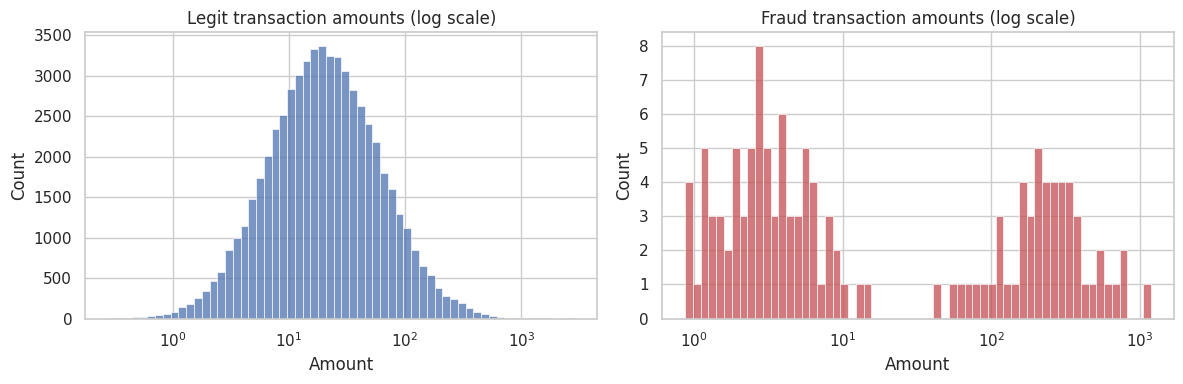

         count        mean         std   min   25%    50%     75%      max
Class                                                                     
0      59871.0   36.954567   58.350424  0.28  9.47  19.79   42.06  2856.69
1        129.0  119.115271  196.217341  0.87  2.62   6.39  197.55  1186.98


In [4]:
# 2.2 Transaction amount: fraud vs legit
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df[df.Class == 0]["Amount"], bins=60, ax=ax[0], color="#4C72B0", log_scale=(True, False))
ax[0].set_title("Legit transaction amounts (log scale)")
sns.histplot(df[df.Class == 1]["Amount"], bins=60, ax=ax[1], color="#C44E52", log_scale=(True, False))
ax[1].set_title("Fraud transaction amounts (log scale)")
plt.tight_layout()
plt.savefig("outputs/02_amount_distribution.png", dpi=120)
plt.show()

print(df.groupby("Class")["Amount"].describe())

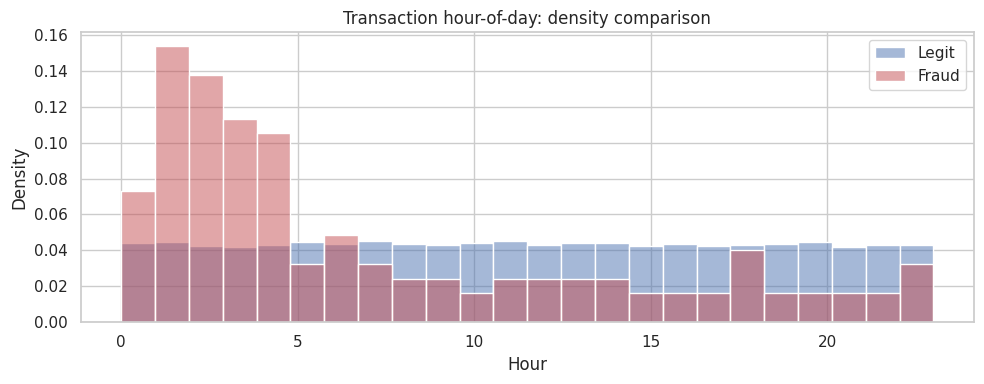

In [5]:
# 2.3 Time-of-day pattern
df["Hour"] = (df["Time"] // 3600) % 24
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(df[df.Class == 0]["Hour"], bins=24, stat="density", color="#4C72B0",
             label="Legit", alpha=0.5, ax=ax)
sns.histplot(df[df.Class == 1]["Hour"], bins=24, stat="density", color="#C44E52",
             label="Fraud", alpha=0.5, ax=ax)
ax.set_title("Transaction hour-of-day: density comparison")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/03_time_pattern.png", dpi=120)
plt.show()

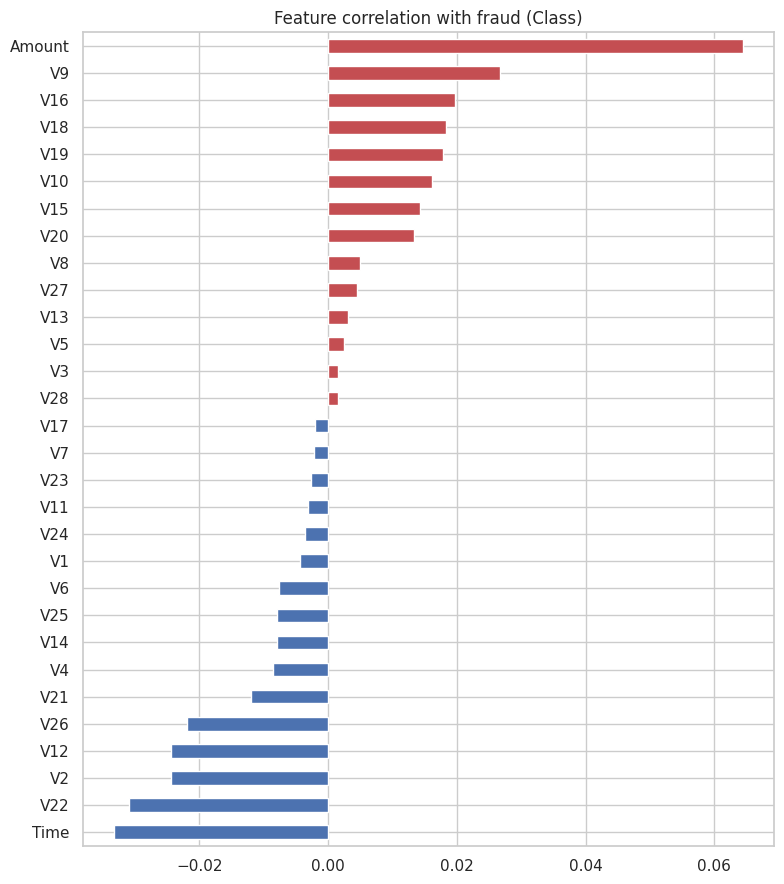

In [6]:
# 2.4 Correlation of top features with fraud
corr = df.drop(columns=["Hour"]).corr()["Class"].drop("Class").sort_values()
fig, ax = plt.subplots(figsize=(8, 9))
corr.plot(kind="barh", ax=ax, color=np.where(corr > 0, "#C44E52", "#4C72B0"))
ax.set_title("Feature correlation with fraud (Class)")
plt.tight_layout()
plt.savefig("outputs/04_feature_correlation.png", dpi=120)
plt.show()

## 3. Train/test split + scaling

Split **before** any resampling — SMOTE etc. must only ever be fit on the *training* fold.
Applying it before splitting leaks synthetic near-duplicates of test fraud into training and
inflates every metric you'll report.

In [7]:
feature_cols = [c for c in df.columns if c not in ("Class", "Hour")]
X = df[feature_cols]
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("Train:", X_train.shape, "  Fraud in train:", y_train.sum())
print("Test: ", X_test.shape, "  Fraud in test: ", y_test.sum())

Train: (45000, 30)   Fraud in train: 97
Test:  (15000, 30)   Fraud in test:  32


## 4. Handling the imbalance

We compare four resampling strategies plus one built-in class-weighting approach:

| Technique | Idea |
|---|---|
| Random undersampling | Drop majority-class rows until balanced (fast, but throws away data) |
| SMOTE | Synthesize new minority (fraud) examples by interpolating between real ones |
| ADASYN | Like SMOTE, but generates more synthetic points near the *hardest* (borderline) examples |
| SMOTE + Tomek links | SMOTE, then clean up overlapping pairs at the class boundary |
| Class-weighting | No resampling — just tell the model to penalize missed fraud more heavily |


In [8]:
resamplers = {
    "Random Undersampling": RandomUnderSampler(random_state=RANDOM_STATE),
    "SMOTE": SMOTE(random_state=RANDOM_STATE),
    "ADASYN": ADASYN(random_state=RANDOM_STATE),
    "SMOTE+Tomek": SMOTETomek(random_state=RANDOM_STATE),
}

resampled_sets = {}
for name, sampler in resamplers.items():
    X_res, y_res = sampler.fit_resample(X_train_scaled, y_train)
    resampled_sets[name] = (X_res, y_res)
    print(f"{name:22s} -> {X_res.shape[0]:,} rows, "
          f"{y_res.mean()*100:.1f}% fraud (was {y_train.mean()*100:.3f}%)")

Random Undersampling   -> 194 rows, 50.0% fraud (was 0.216%)


SMOTE                  -> 89,806 rows, 50.0% fraud (was 0.216%)
ADASYN                 -> 89,838 rows, 50.0% fraud (was 0.216%)


SMOTE+Tomek            -> 89,806 rows, 50.0% fraud (was 0.216%)


## 5. Models

We train **Logistic Regression** (interpretable baseline) and **XGBoost** (usually the strongest
performer on tabular fraud data) on each resampled training set, plus:
- XGBoost with **class-weighting** instead of resampling (`scale_pos_weight`)
- **Isolation Forest**, an *unsupervised* anomaly-detection model that never sees labels during
  training — useful when you don't trust your fraud labels or want to catch novel fraud patterns.


In [9]:
def evaluate_model(name, y_true, y_scores, threshold=0.5):
    y_pred = (y_scores >= threshold).astype(int)
    ap = average_precision_score(y_true, y_scores)
    f1 = f1_score(y_true, y_pred)
    roc = roc_auc_score(y_true, y_scores)
    cm = confusion_matrix(y_true, y_pred)
    return {"name": name, "avg_precision": ap, "f1": f1, "roc_auc": roc,
            "confusion_matrix": cm, "y_scores": y_scores}

results = []

for res_name, (X_res, y_res) in resampled_sets.items():
    # Logistic Regression
    lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    lr.fit(X_res, y_res)
    scores = lr.predict_proba(X_test_scaled)[:, 1]
    results.append(evaluate_model(f"LogReg + {res_name}", y_test, scores))

    # XGBoost
    xgb_clf = xgb.XGBClassifier(
        n_estimators=120, max_depth=5, learning_rate=0.1,
        eval_metric="aucpr", random_state=RANDOM_STATE, n_jobs=-1
    )
    xgb_clf.fit(X_res, y_res)
    scores = xgb_clf.predict_proba(X_test_scaled)[:, 1]
    results.append(evaluate_model(f"XGBoost + {res_name}", y_test, scores))

# XGBoost with class weighting instead of resampling
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_weighted = xgb.XGBClassifier(
    n_estimators=120, max_depth=5, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, eval_metric="aucpr",
    random_state=RANDOM_STATE, n_jobs=-1
)
xgb_weighted.fit(X_train_scaled, y_train)
scores = xgb_weighted.predict_proba(X_test_scaled)[:, 1]
results.append(evaluate_model("XGBoost + class_weight (no resampling)", y_test, scores))

# Isolation Forest (unsupervised — trained with NO labels)
iso = IsolationForest(
    n_estimators=120, contamination=y_train.mean(), random_state=RANDOM_STATE
)
iso.fit(X_train_scaled)
# lower (more negative) decision_function score = more anomalous -> flip sign to act like a fraud score
iso_scores = -iso.decision_function(X_test_scaled)
iso_scores = (iso_scores - iso_scores.min()) / (iso_scores.max() - iso_scores.min())
results.append(evaluate_model("Isolation Forest (unsupervised)", y_test, iso_scores))

print(f"Trained {len(results)} model/resampling combinations.")

Trained 10 model/resampling combinations.


## 6. Model comparison

**Why not accuracy?** With 99.8%+ legit transactions, accuracy is meaningless (see Section 2).
Instead we compare:
- **Average Precision (area under the Precision-Recall curve)** — the single best summary metric
  for severe imbalance
- **ROC-AUC** — included for reference, but less informative than AP here
- **F1 @ 0.5 threshold** — a snapshot at the default cutoff (we'll tune the threshold properly in
  Section 7)


In [10]:
summary = pd.DataFrame([
    {"Model": r["name"], "Avg Precision (PR-AUC)": r["avg_precision"],
     "ROC-AUC": r["roc_auc"], "F1 @ 0.5": r["f1"]}
    for r in results
]).sort_values("Avg Precision (PR-AUC)", ascending=False).reset_index(drop=True)

summary.style.background_gradient(subset=["Avg Precision (PR-AUC)"], cmap="Greens")

,Model,Avg Precision (PR-AUC),ROC-AUC,F1 @ 0.5
0,XGBoost + class_weight (no resampling),0.121767,0.914948,0.218182
1,XGBoost + ADASYN,0.046551,0.867202,0.069869
2,XGBoost + SMOTE+Tomek,0.038366,0.858337,0.082949
3,XGBoost + SMOTE,0.038366,0.858337,0.082949
4,XGBoost + Random Undersampling,0.037189,0.889036,0.020947
5,LogReg + ADASYN,0.036389,0.815859,0.013158
6,LogReg + SMOTE+Tomek,0.034240,0.816049,0.013438
7,LogReg + SMOTE,0.034240,0.816049,0.013438
8,LogReg + Random Undersampling,0.017968,0.796794,0.011343
9,Isolation Forest (unsupervised),0.007034,0.633460,0.011905


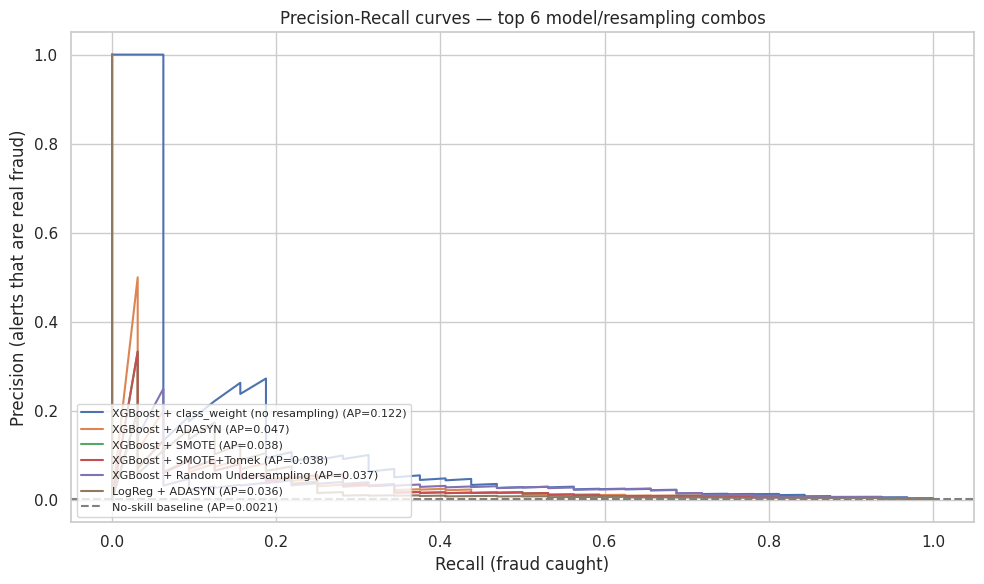

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
top_results = sorted(results, key=lambda r: r["avg_precision"], reverse=True)[:6]
for r in top_results:
    precision, recall, _ = precision_recall_curve(y_test, r["y_scores"])
    ax.plot(recall, precision, label=f"{r['name']} (AP={r['avg_precision']:.3f})")

baseline = y_test.mean()
ax.axhline(baseline, color="gray", linestyle="--", label=f"No-skill baseline (AP={baseline:.4f})")
ax.set_xlabel("Recall (fraud caught)")
ax.set_ylabel("Precision (alerts that are real fraud)")
ax.set_title("Precision-Recall curves — top 6 model/resampling combos")
ax.legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.savefig("outputs/05_precision_recall_curves.png", dpi=120)
plt.show()

## 7. The precision/recall tradeoff — picking an operating threshold

This is the business decision that actually matters. Two failure modes:
- **False Negative** (missed fraud): the bank eats the loss, e.g. average $150/transaction
- **False Positive** (legit transaction blocked/flagged): customer friction — a support call,
  a declined purchase, lost trust; estimate ~$5 cost per false alarm (review + customer service)

We pick the **best model** from Section 6 and sweep its threshold to find the cost-minimizing
cutoff, instead of blindly using 0.5.

Best model: XGBoost + class_weight (no resampling)


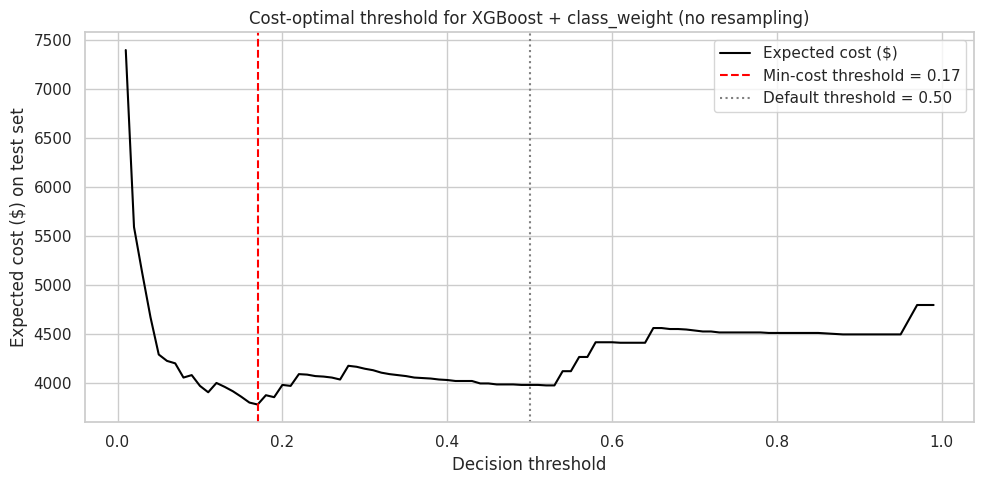

Default threshold (0.50): cost = $3,985
Cost-optimal threshold (0.17): cost = $3,785
Savings from tuning the threshold: $200


In [12]:
best = top_results[0]
print("Best model:", best["name"])

FN_COST = 150   # cost of missing a fraud
FP_COST = 5     # cost of a false alarm

thresholds = np.linspace(0.01, 0.99, 99)
costs, precisions, recalls = [], [], []

for t in thresholds:
    y_pred = (best["y_scores"] >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    cost = fn * FN_COST + fp * FP_COST
    costs.append(cost)
    precisions.append(tp / (tp + fp) if (tp + fp) else np.nan)
    recalls.append(tp / (tp + fn) if (tp + fn) else np.nan)

best_idx = int(np.argmin(costs))
best_threshold = thresholds[best_idx]

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(thresholds, costs, color="black", label="Expected cost ($)")
ax1.axvline(best_threshold, color="red", linestyle="--",
            label=f"Min-cost threshold = {best_threshold:.2f}")
ax1.axvline(0.5, color="gray", linestyle=":", label="Default threshold = 0.50")
ax1.set_xlabel("Decision threshold")
ax1.set_ylabel("Expected cost ($) on test set")
ax1.set_title(f"Cost-optimal threshold for {best['name']}")
ax1.legend()
plt.tight_layout()
plt.savefig("outputs/06_cost_threshold.png", dpi=120)
plt.show()

print(f"Default threshold (0.50): cost = ${costs[np.argmin(np.abs(thresholds-0.5))]:,.0f}")
print(f"Cost-optimal threshold ({best_threshold:.2f}): cost = ${costs[best_idx]:,.0f}")
print(f"Savings from tuning the threshold: "
      f"${costs[np.argmin(np.abs(thresholds-0.5))] - costs[best_idx]:,.0f}")

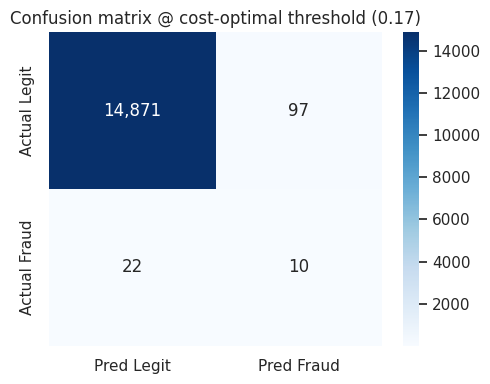

              precision    recall  f1-score   support

       Legit       1.00      0.99      1.00     14968
       Fraud       0.09      0.31      0.14        32

    accuracy                           0.99     15000
   macro avg       0.55      0.65      0.57     15000
weighted avg       1.00      0.99      0.99     15000



In [13]:
y_pred_optimal = (best["y_scores"] >= best_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_optimal)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt=",", cmap="Blues",
            xticklabels=["Pred Legit", "Pred Fraud"],
            yticklabels=["Actual Legit", "Actual Fraud"], ax=ax)
ax.set_title(f"Confusion matrix @ cost-optimal threshold ({best_threshold:.2f})")
plt.tight_layout()
plt.savefig("outputs/07_confusion_matrix.png", dpi=120)
plt.show()

print(classification_report(y_test, y_pred_optimal, target_names=["Legit", "Fraud"]))

## 8. Explainability with SHAP

For a fraud model, "the model said so" is never good enough — a real system needs to explain
*why* a specific transaction was flagged (for analysts, regulators, and customers). We use SHAP
values on a tree-based model (XGBoost) trained on the best resampling strategy.

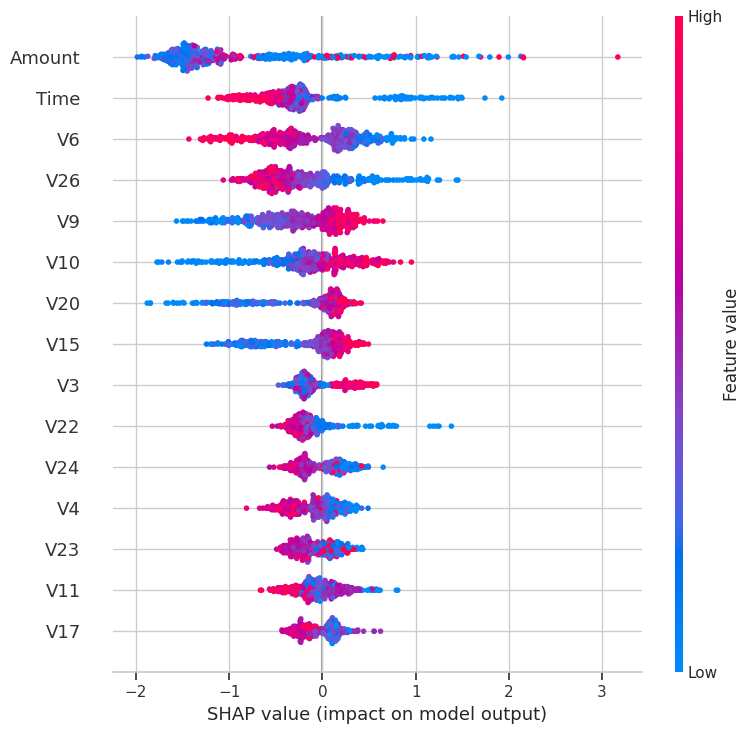

In [14]:
import shap

# retrain the winning XGBoost config cleanly for SHAP (tree_path_dependent is fast + exact for trees)
best_resampling_name = best["name"].split(" + ")[-1] if "XGBoost" in best["name"] else "SMOTE"
if best_resampling_name in resampled_sets:
    X_res, y_res = resampled_sets[best_resampling_name]
else:
    X_res, y_res = X_train_scaled, y_train

shap_model = xgb.XGBClassifier(
    n_estimators=120, max_depth=5, learning_rate=0.1,
    eval_metric="aucpr", random_state=RANDOM_STATE, n_jobs=-1
)
shap_model.fit(X_res, y_res)

explainer = shap.TreeExplainer(shap_model)
sample = X_test_scaled.sample(min(500, len(X_test_scaled)), random_state=RANDOM_STATE)
shap_values = explainer.shap_values(sample)

shap.summary_plot(shap_values, sample, show=False, max_display=15)
plt.tight_layout()
plt.savefig("outputs/08_shap_summary.png", dpi=120, bbox_inches="tight")
plt.show()

Top features driving THIS transaction's fraud score:
Amount    1.155023
V4       -0.590031
V18      -0.570560
Time     -0.458700
V15      -0.418302
V3       -0.298232
V26      -0.285090
V22      -0.281574
dtype: float32


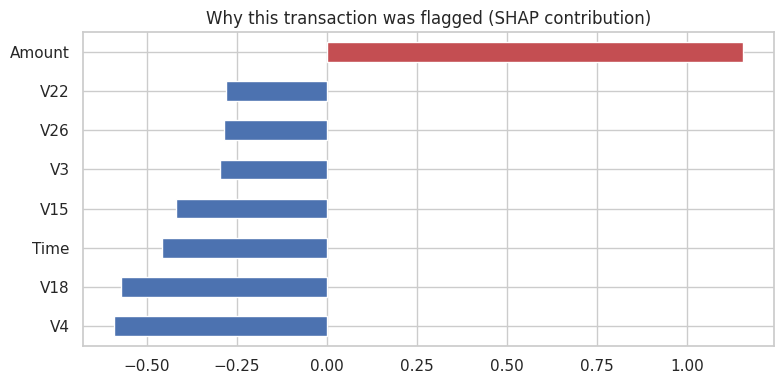

In [15]:
# Explain a single flagged fraud case -- exactly what an analyst / the Streamlit app would show
fraud_idx_in_test = y_test[y_test == 1].index[0]
row = X_test_scaled.loc[[fraud_idx_in_test]]
row_shap = explainer.shap_values(row)

contrib = pd.Series(row_shap[0], index=row.columns).sort_values(key=abs, ascending=False).head(8)
print("Top features driving THIS transaction's fraud score:")
print(contrib)

fig, ax = plt.subplots(figsize=(8, 4))
contrib.sort_values().plot(kind="barh", ax=ax,
                            color=np.where(contrib.sort_values() > 0, "#C44E52", "#4C72B0"))
ax.set_title("Why this transaction was flagged (SHAP contribution)")
plt.tight_layout()
plt.savefig("outputs/09_single_case_explanation.png", dpi=120)
plt.show()

## 9. Save the final model + artifacts

Persist the winning model, scaler, and chosen threshold so the Streamlit app (`app/streamlit_app.py`)
can load them directly without retraining.

In [16]:
import joblib

joblib.dump(shap_model, "models/fraud_xgb_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")
joblib.dump({"threshold": float(best_threshold), "feature_cols": feature_cols},
            "models/model_config.pkl")

print("Saved: models/fraud_xgb_model.pkl, models/scaler.pkl, models/model_config.pkl")

Saved: models/fraud_xgb_model.pkl, models/scaler.pkl, models/model_config.pkl


## 10. Summary & next steps

**What we learned:**
- Accuracy is meaningless at 0.2% fraud — Average Precision / PR-AUC is the metric that matters
- Resampling technique choice matters, but so does the model: XGBoost consistently outperforms
  Logistic Regression regardless of resampling strategy
- The "right" decision threshold is a **business** question, not a data-science one — tying it to
  a real cost model (false negative vs. false positive cost) beats using a default 0.5 cutoff
- SHAP turns a black-box score into an auditable explanation, which real fraud systems require

**Natural extensions:**
- Try a deep learning autoencoder (reconstruction error as anomaly score) as another unsupervised baseline
- Add temporal / graph features (e.g., transaction velocity per card, merchant network features)
- Move from a single train/test split to time-based cross-validation (fraud patterns drift over time)
- Wrap the model behind a FastAPI endpoint for real-time scoring in production
